## Configuracion

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from quant_utils import FinancialStats

sns.set_theme(style="darkgrid")

# Parámetros fijos de dos activos
retorno_A = 0.10
retorno_B = 0.10
vol_A = 0.20
vol_B = 0.20

# Vector de pesos equitativo (50% en cada uno)
w = np.array([0.5, 0.5])

## Impacto de la correlacion (Simulacion Analitica)

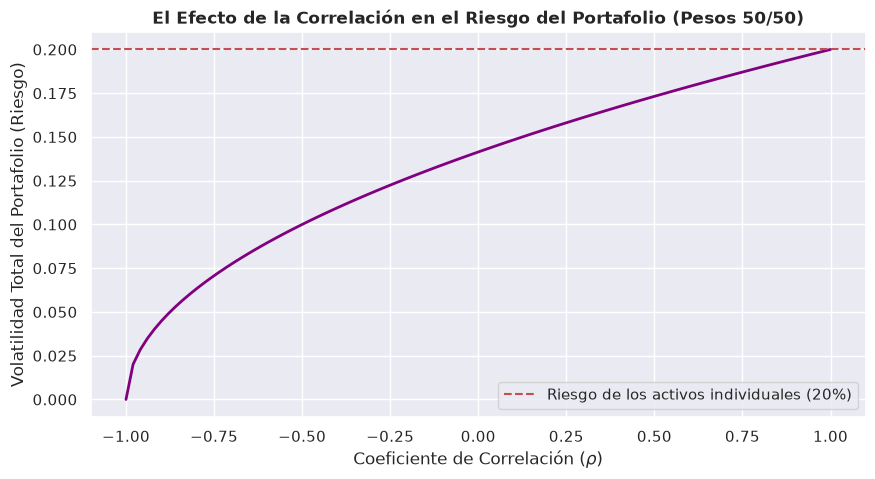

In [4]:
correlaciones = np.linspace(-1, 1, 100)
riesgos_portafolio = []

for rho in correlaciones:
    # Construimos la matriz de covarianza manualmente usando la fórmula: 
    cov_AB = rho * vol_A * vol_B
    
    # Matriz Sigma de 2x2
    sigma = np.array([
        [vol_A**2, cov_AB],
        [cov_AB,   vol_B**2]
    ])
    
    # Calculamos el riesgo de la forma cuadrática: sqrt(w^T * Sigma * w)
    varianza_p = np.dot(w.T, np.dot(sigma, w))
    vol_p = np.sqrt(varianza_p)
    riesgos_portafolio.append(vol_p)

# Graficar el resultado matemático
plt.figure(figsize=(10, 5))
plt.plot(correlaciones, riesgos_portafolio, color='purple', linewidth=2)
plt.title('El Efecto de la Correlación en el Riesgo del Portafolio (Pesos 50/50)', fontsize=12, fontweight='bold')
plt.xlabel('Coeficiente de Correlación ($\\rho$)')
plt.ylabel('Volatilidad Total del Portafolio (Riesgo)')
plt.axhline(y=0.20, color='r', linestyle='--', label='Riesgo de los activos individuales (20%)')
plt.legend()
plt.show()

- En $\rho = 1.0$ (Extremo derecho): La curva toca exactamente la línea punteada roja ($20\%$). No hay beneficio de diversificación. Si metés dos activos idénticos, tu portafolio se mueve exactamente igual que si tuvieras uno solo.
- En $\rho = 0.0$ (El centro): Podés ver en tu eje Y que la volatilidad ya bajó a un valor cercano al $14.14\%$ ($\frac{0.20}{\sqrt{2}}$ para ser exactos con pesos 50/50). Sin necesidad de correlaciones negativas (solo con que los activos sean independientes), ya le podaste casi un $30\%$ de riesgo a tu cartera manteniendo el mismo retorno del $10\%$. Esto es lo que la industria llama "el único almuerzo gratis en las finanzas".
- La caída abrupta cerca de $\rho = -1.0$ (Extremo izquierdo): Notá cómo la curva se desploma hacia el cero de forma súper empinada al final. Cuando la correlación se acerca a la negatividad perfecta, los activos se transforman en "espejos opuestos". Las subas de uno cancelan con precisión matemática las bajas del otro, logrando que la volatilidad total colapse a $0.0$.

## Configuración de 3 Activos con Retornos Diferentes

Para que el grafico tenga sentido real, vamos a darle a cada activo un perfil distinto de riesgo y de retorno.

- Activo A (Tecnológica agresiva): Mucho retorno ($15\%$), mucho riesgo ($25\%$).
- Activo B (Consumo defensivo): Retorno moderado ($8\%$), riesgo medio ($12\%$).
- Activo C (Bono/Oro): Retorno bajo ($4\%$), riesgo bajo ($8\%$).

In [5]:
# 1. Definimos los retornos esperados de cada uno
retornos_esperados = np.array([0.15, 0.08, 0.04]) # A, B, C

# 2. Definimos sus volatilidades individuales
vols = np.array([0.25, 0.12, 0.08])

# 3. Definimos una matriz de correlación realista entre ellos
# Notá que el Activo C tiene correlación casi nula o baja con el resto (buen diversificador)
matriz_correlacion = np.array([
    [1.0,  0.4,  0.1],  # A
    [0.4,  1.0,  0.2],  # B
    [0.1,  0.2,  1.0]   # C
])

# 4. Reconstruimos la Matriz de Covarianza (Sigma) usando álgebra lineal:
# Sigma = Diag(Vols) * Correlacion * Diag(Vols)
D = np.diag(vols)
sigma = np.dot(D, np.dot(matriz_correlacion, D))

## Simluacion de Monte Carlo

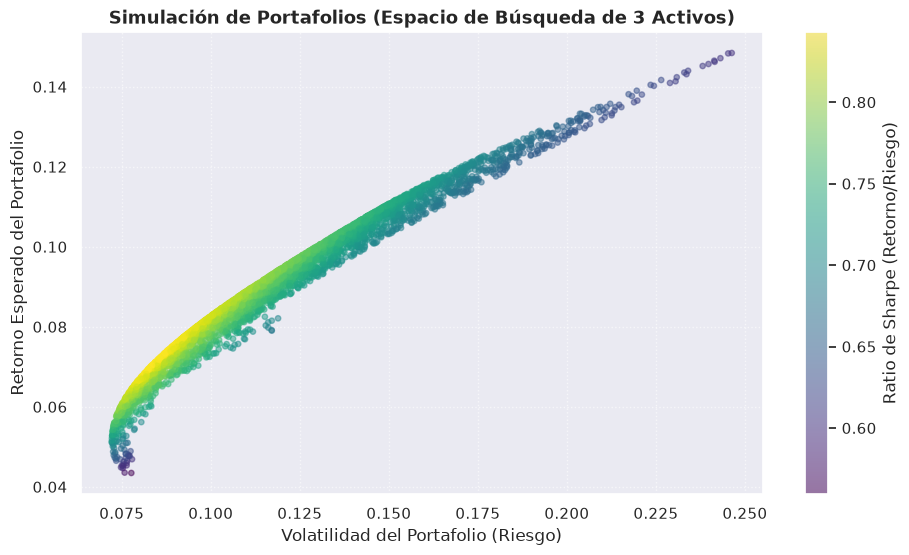

In [6]:
num_portafolios = 5000
resultados_ret = []
resultados_vol = []

for _ in range(num_portafolios):
    # Generamos 3 números aleatorios entre 0 y 1
    pesos = np.random.random(3)
    # Normalizamos para que sumen 1 (Constraint de capital)
    pesos /= np.sum(pesos)
    
    # Cálculo del retorno esperado del portafolio: w^T * R
    ret_p = np.dot(pesos, retornos_esperados)
    
    # Cálculo del riesgo del portafolio: sqrt(w^T * Sigma * w)
    var_p = np.dot(pesos.T, np.dot(sigma, pesos))
    vol_p = np.sqrt(var_p)
    
    resultados_ret.append(ret_p)
    resultados_vol.append(vol_p)

# Graficamos la nube de posibilidades
plt.figure(figsize=(11, 6))
plt.scatter(resultados_vol, resultados_ret, c=resultados_ret/np.array(resultados_vol), 
            cmap='viridis', marker='o', s=15, alpha=0.5)

plt.title('Simulación de Portafolios (Espacio de Búsqueda de 3 Activos)', fontsize=13, fontweight='bold')
plt.xlabel('Volatilidad del Portafolio (Riesgo)')
plt.ylabel('Retorno Esperado del Portafolio')
plt.colorbar(label='Ratio de Sharpe (Retorno/Riesgo)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

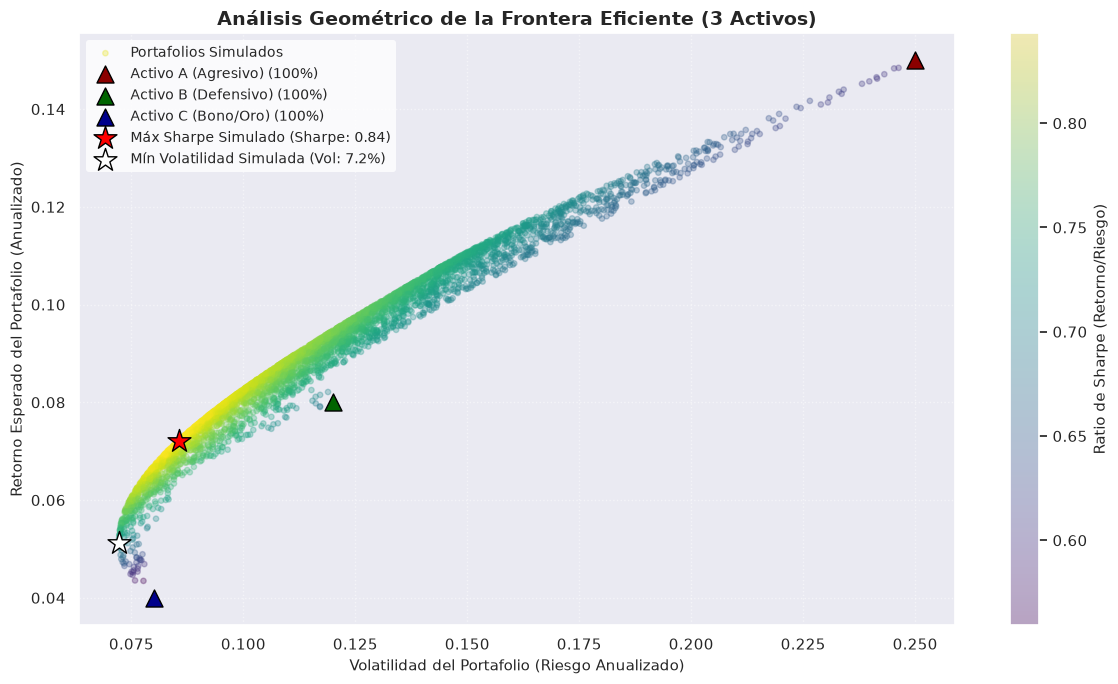

In [7]:
# Celda 4 Mejorada: Visualización Avanzada de la Frontera Eficiente

# 1. Encontrar los índices de los puntos clave simulados para marcarlos
lista_sharpe = np.array(resultados_ret) / np.array(resultados_vol)
idx_max_sharpe = np.argmax(lista_sharpe)
idx_min_vol = np.argmin(resultados_vol)

# 2. Iniciar el gráfico
plt.figure(figsize=(12, 7))

# Capa 1: La nube de portafolios de fondo
scatter = plt.scatter(resultados_vol, resultados_ret, c=lista_sharpe, 
                      cmap='viridis', marker='o', s=15, alpha=0.3, label='Portafolios Simulados')
cbar = plt.colorbar(scatter)
cbar.set_label('Ratio de Sharpe (Retorno/Riesgo)', fontsize=11)

# Capa 2: Dibujar los 3 Activos Puros (100% de asignación en cada uno)
nombres_activos = ['Activo A (Agresivo)', 'Activo B (Defensivo)', 'Activo C (Bono/Oro)']
colores_activos = ['darkred', 'darkgreen', 'darkblue']

for i in range(3):
    plt.scatter(vols[i], retornos_esperados[i], color=colores_activos[i], 
                marker='^', s=150, edgecolor='black', zorder=5,
                label=f'{nombres_activos[i]} (100%)')

# Capa 3: Resaltar el Máximo Sharpe Simulado (Estrella Roja)
plt.scatter(resultados_vol[idx_max_sharpe], resultados_ret[idx_max_sharpe], 
            color='red', marker='*', s=300, edgecolor='black', zorder=6,
            label=f'Máx Sharpe Simulado (Sharpe: {lista_sharpe[idx_max_sharpe]:.2f})')

# Capa 4: Resaltar la Mínima Volatilidad Simulada (Estrella Blanca)
plt.scatter(resultados_vol[idx_min_vol], resultados_ret[idx_min_vol], 
            color='white', marker='*', s=300, edgecolor='black', zorder=6,
            label=f'Mín Volatilidad Simulada (Vol: {resultados_vol[idx_min_vol]*100:.1f}%)')

# Estética y anotaciones de ingeniería
plt.title('Análisis Geométrico de la Frontera Eficiente (3 Activos)', fontsize=14, fontweight='bold')
plt.xlabel('Volatilidad del Portafolio (Riesgo Anualizado)', fontsize=11)
plt.ylabel('Retorno Esperado del Portafolio (Anualizado)', fontsize=11)
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()